In [35]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# CHEME 485 4 Stream Lunar O2 Process Thermal Design
# Modify the "Execution" block at end of cell to change stream
# values
# ------------------------------------------------------------
def get_lmtd(Th1, Th2, Tc1, Tc2):
    dt1, dt2 = Th1 - Tc2, Th2 - Tc1
    if dt1 <= 0 or dt2 <= 0: return None
    if abs(dt1 - dt2) < 1e-6: return dt1
    return (dt1 - dt2) / np.log(dt1 / dt2)

def get_eps(ntu, Cr):
    if abs(Cr - 1.0) < 1e-8: return ntu / (1 + ntu)
    return (1 - np.exp(-ntu * (1 - Cr))) / (1 - Cr * np.exp(-ntu * (1 - Cr)))

# ------------------------------------------------------------
# MAIN PIPELINE FUNCTION (7-UNIT PINCH-AWARE VERSION)
# ------------------------------------------------------------
def run_full_regolith_pipeline(streams, DTmin=20, U=0.20, A_example=77.0):
    print("\n" + "="*30 + "\nINPUT STREAMS\n" + "="*30)
    print(streams[["name", "type", "Tin", "Tout", "C", "Q"]], "\n")

    # 1. Shift temperatures
    streams = streams.copy()
    streams["Tin_shift"] = np.where(streams["type"] == "hot", streams["Tin"] - DTmin/2, streams["Tin"] + DTmin/2)
    streams["Tout_shift"] = np.where(streams["type"] == "hot", streams["Tout"] - DTmin/2, streams["Tout"] + DTmin/2)

    # 2. Build temperature intervals
    temps = sorted(set(streams["Tin_shift"]).union(set(streams["Tout_shift"])), reverse=True)
    intervals = pd.DataFrame({"T_high": temps[:-1], "T_low": temps[1:]})
    intervals["dT"] = intervals["T_high"] - intervals["T_low"]

    # 3. Heat Balance (dH)
    def is_active(s, T_low, T_high):
        s_low, s_high = min(s["Tin_shift"], s["Tout_shift"]), max(s["Tin_shift"], s["Tout_shift"])
        return not (s_high <= T_low or s_low >= T_high)

    dH_list = []
    for _, interval in intervals.iterrows():
        cp_hot = streams[(streams["type"] == "hot") & (streams.apply(lambda s: is_active(s, interval["T_low"], interval["T_high"]), axis=1))]["C"].sum()
        cp_cold = streams[(streams["type"] == "cold") & (streams.apply(lambda s: is_active(s, interval["T_low"], interval["T_high"]), axis=1))]["C"].sum()
        dH_list.append((cp_hot - cp_cold) * interval["dT"])
    intervals["dH"] = dH_list

    # 4. Heat cascade (MER)
    cascade = [0]
    for dH in intervals["dH"]: cascade.append(cascade[-1] + dH)
    cascade = np.array(cascade)
    shift = -cascade.min() if cascade.min() < 0 else 0
    cascade_shifted = cascade + shift

    MER_hot, MER_cold = cascade_shifted[0], cascade_shifted[-1]
    pinch_temp = temps[np.argmin(cascade_shifted)]
    hot_p, cold_p = pinch_temp + DTmin/2, pinch_temp - DTmin/2

    print("="*30 + "\nMER RESULTS\n" + "="*30)
    print(f"Hot Utility Target (QHmin):  {MER_hot:.2f} kW")
    print(f"Cold Utility Target (QCmin): {MER_cold:.2f} kW")
    print(f"Actual Pinch Boundary:      Hot {hot_p}°C / Cold {cold_p}°C\n")

    # --------------------------------------------------------
    # 5. SELECTIVE MATCH ALLOCATION (N_min = 7 Design)
    # --------------------------------------------------------
    matches = {}
    hot_p, cold_p = pinch_temp + DTmin/2, pinch_temp - DTmin/2

    # Get lists of streams above/below pinch
    h_above = streams[(streams["type"] == "hot") & (streams["Tin"] > hot_p)].copy()
    c_above = streams[(streams["type"] == "cold") & (streams["Tout"] > cold_p)].copy()
    
    h_below = streams[(streams["type"] == "hot") & (streams["Tout"] < hot_p)].copy()
    c_below = streams[(streams["type"] == "cold") & (streams["Tin"] < cold_p)].copy()

    # --- ZONE A: ABOVE PINCH (Selective 1-to-1) ---
    # Strategy: Pair Reactor (Big Hot) with Regolith (Big Cold) first
    for h_name in ["Reactor_Exit"]:
        for c_name in ["Regolith_Feed", "Hydrogen_Feed"]:
            h = h_above[h_above["name"] == h_name].iloc[0]
            c = c_above[c_above["name"] == c_name].iloc[0]
            
            q_avail = h["C"] * (h["Tin"] - hot_p)
            q_need  = c["C"] * (c["Tout"] - cold_p)
            q_match = min(q_avail, q_need)
            
            if q_match > 1.0:
                matches[(f"{h_name}_High", c_name)] = {
                    'Q': q_match, 'Th_in': h["Tin"], 'Th_out': hot_p,
                    'Tc_in': cold_p, 'Tc_out': c["Tout"], 
                    'orig_h': h_name, 'orig_c': c_name, 'zone': 'Above'
                }

    # --- ZONE B: BELOW PINCH (Selective 1-to-1) ---
    # Strategy: Pair Electrolyzer with Hydrogen first to simplify the network
    pairings_below = [("Electrolyzer", "Hydrogen_Feed"), ("Reactor_Exit", "Regolith_Feed")]
    
    for h_name, c_name in pairings_below:
        h_rows = h_below[h_below["name"] == h_name]
        c_rows = c_below[c_below["name"] == c_name]
        
        if not h_rows.empty and not c_rows.empty:
            h, c = h_rows.iloc[0], c_rows.iloc[0]
            q_avail = h["C"] * (hot_p - h["Tout"])
            q_need  = c["C"] * (cold_p - c["Tin"])
            q_match = min(q_avail, q_need)
            
            if q_match > 1.0:
                matches[(f"{h_name}_Low", c_name)] = {
                    'Q': q_match, 'Th_in': hot_p, 'Th_out': h["Tout"],
                    'Tc_in': c["Tin"], 'Tc_out': cold_p,
                    'orig_h': h_name, 'orig_c': c_name, 'zone': 'Below'
                }


    # 6. Sizing and Rating (Fixed Lookup)
    print("="*30 + "\nEXCHANGER SIZING & RATING\n" + "="*30)
    for (h_label, c_n), m in matches.items():
        dt_lm = get_lmtd(m['Th_in'], m['Th_out'], m['Tc_in'], m['Tc_out'])
        # Lookup original stream C values using the 'orig' keys
        Ch = streams.loc[streams["name"] == m['orig_h'], "C"].values[0]
        Cc = streams.loc[streams["name"] == m['orig_c'], "C"].values[0]
        Cmin, Cr = min(Ch, Cc), min(Ch, Cc)/max(Ch, Cc)
        ntu = (U * A_example) / Cmin
        eps = get_eps(ntu, Cr)

        status = f"LMTD: {dt_lm:.1f} K | Area: {m['Q']/(U*dt_lm):.1f} m²" if dt_lm else "PINCH VIOLATION"
        print(f"Match {h_label} ↔ {c_n}:")
        print(f"  Load: {m['Q']:.1f} kW | {status} | ε={eps:.2f}\n")

    return streams, intervals, MER_hot, MER_cold, pinch_temp, temps, matches

# --- EXECUTION ---
raw_data = [
    {"name": "Reactor_Exit",   "type": "hot",  "Tin": 900.0, "Tout": 40.0, "Q": 1200.0},
    {"name": "Electrolyzer",   "type": "hot",  "Tin": 80.0,  "Tout": 40.0,  "Q": 300.0},
    {"name": "Regolith_Feed",  "type": "cold", "Tin": 40.0,  "Tout": 800.0, "Q": 1000.0},
    {"name": "Hydrogen_Feed",  "type": "cold", "Tin": 30.0,  "Tout": 900.0, "Q": 500.0},
]
my_streams = pd.DataFrame(raw_data)
my_streams["C"] = my_streams["Q"] / (my_streams["Tin"] - my_streams["Tout"]).abs()

streams_df, intervals_df, q_hot_min, q_cold_min, pinch_t, temps_list, matches = run_full_regolith_pipeline(my_streams)



INPUT STREAMS
            name  type    Tin   Tout         C       Q
0   Reactor_Exit   hot  900.0   40.0  1.395349  1200.0
1   Electrolyzer   hot   80.0   40.0  7.500000   300.0
2  Regolith_Feed  cold   40.0  800.0  1.315789  1000.0
3  Hydrogen_Feed  cold   30.0  900.0  0.574713   500.0 

MER RESULTS
Hot Utility Target (QHmin):  312.26 kW
Cold Utility Target (QCmin): 312.26 kW
Actual Pinch Boundary:      Hot 80.0°C / Cold 60.0°C

EXCHANGER SIZING & RATING
Match Reactor_Exit_High ↔ Regolith_Feed:
  Load: 973.7 kW | LMTD: 49.7 K | Area: 97.9 m² | ε=0.94

Match Reactor_Exit_High ↔ Hydrogen_Feed:
  Load: 482.8 kW | PINCH VIOLATION | ε=1.00

Match Electrolyzer_Low ↔ Hydrogen_Feed:
  Load: 17.2 kW | LMTD: 14.4 K | Area: 6.0 m² | ε=1.00

Match Reactor_Exit_Low ↔ Regolith_Feed:
  Load: 26.3 kW | PINCH VIOLATION | ε=0.94



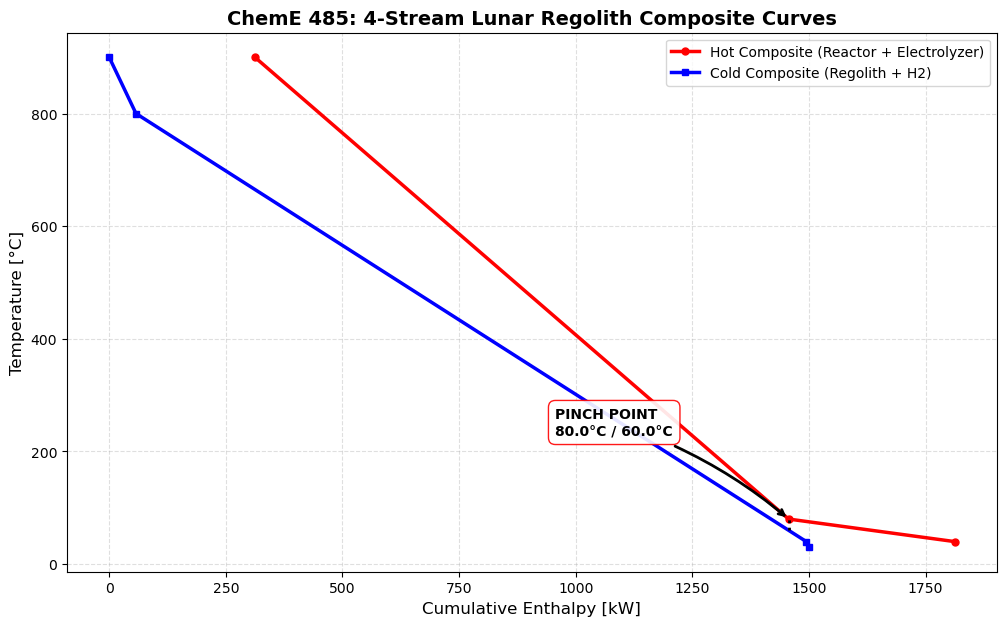

DEBUG: Pinch successfully plotted at Q = 1456.44 kW


In [36]:
import matplotlib.pyplot as plt
import numpy as np

def plot_4stream_final(df, q_hmin, p_temp, dt_min):
    try:
        plt.figure(figsize=(12, 7))
        
        # 1. Fixed Helper to build coordinates (Corrected array shapes)
        def get_coords(s_type, offset=0):
            data = df[df["type"] == s_type].copy()
            # Sort temperatures descending (Hottest to Coldest)
            temps = sorted(list(set(data["Tin"]).union(set(data["Tout"]))), reverse=True)
            
            q_list = [offset]
            t_list = [temps[0]] # Start at the highest temperature
            
            for i in range(len(temps)-1):
                t_hi, t_lo = temps[i], temps[i+1]
                # Sum CP of streams active in this slice
                active_mask = (data[["Tin", "Tout"]].max(axis=1) >= t_hi) & \
                              (data[["Tin", "Tout"]].min(axis=1) <= t_lo)
                cp_sum = data[active_mask]["C"].sum()
                
                q_list.append(q_list[-1] + cp_sum * (t_hi - t_lo))
                t_list.append(t_lo)
                
            return np.array(q_list), np.array(t_list)

        # Generate Curves
        h_q, h_t = get_coords("hot", offset=q_hmin)
        c_q, c_t = get_coords("cold", offset=0)

        # 2. CALCULATE PINCH Q (Targeting ~1375 kW)
        # The Pinch is at Actual Hot Temp (p_temp + dt_min/2)
        hot_pinch_t = p_temp + dt_min/2
        cold_pinch_t = p_temp - dt_min/2
        
        # Calculate Enthalpy of Hot Curve from the top down to the pinch
        h_data = df[df["type"] == "hot"]
        duty_above_pinch = 0
        for _, s in h_data.iterrows():
            hi, lo = max(s["Tin"], s["Tout"]), min(s["Tin"], s["Tout"])
            if hi > hot_pinch_t:
                active_lo = max(lo, hot_pinch_t)
                duty_above_pinch += s["C"] * (hi - active_lo)
        
        plot_pinch_q = q_hmin + duty_above_pinch

        # 3. Plotting
        plt.plot(h_q, h_t, 'r-o', label='Hot Composite (Reactor + Electrolyzer)', lw=2.5, markersize=5)
        plt.plot(c_q, c_t, 'b-s', label='Cold Composite (Regolith + H2)', lw=2.5, markersize=5)

        # 4. The Arrow (Pointing to the pinch bottleneck on the right)
        plt.annotate(
            f'PINCH POINT\n{hot_pinch_t:.1f}°C / {cold_pinch_t:.1f}°C', 
            xy=(plot_pinch_q, hot_pinch_t), 
            xytext=(plot_pinch_q - 500, hot_pinch_t + 150),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=-0.1", lw=2, color='black'),
            fontweight='bold', bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="red", alpha=0.9)
        )

        plt.vlines(x=plot_pinch_q, ymin=cold_pinch_t, ymax=hot_pinch_t, colors='black', linestyles=':', lw=2)
        
        # 5. Formatting
        plt.title("ChemE 485: 4-Stream Lunar Regolith Composite Curves", fontsize=14, fontweight='bold')
        plt.xlabel("Cumulative Enthalpy [kW]", fontsize=12)
        plt.ylabel("Temperature [°C]", fontsize=12)
        plt.grid(True, which='both', linestyle='--', alpha=0.4)
        plt.legend(loc='best')
        plt.show()
        
        print(f"DEBUG: Pinch successfully plotted at Q = {plot_pinch_q:.2f} kW")

    except Exception as e:
        print(f"ERROR: Plotting failed due to: {e}")

# EXECUTE
plot_4stream_final(streams_df, q_hot_min, pinch_t, 20)

In [37]:
import pandas as pd
import numpy as np

def print_pinch_problem_table(streams, intervals, cascade_shifted, MER_hot):
    print("\n" + "="*85)
    print(f"{'INTERVAL':<10} | {'T_hi':<8} | {'T_lo':<8} | {'dT':<6} | {'CP_net':<10} | {'dH':<10} | {'Heat Flow':<12}")
    print("="*85)
    
    # We iterate through the intervals and the shifted cascade
    # Note: cascade_shifted has one more element than intervals (the boundary points)
    for i, row in intervals.iterrows():
        t_hi = row['T_high']
        t_lo = row['T_low']
        dt   = row['dT']
        dh   = row['dH']
        
        # Calculate CP_net for this specific slice (dH / dT)
        # Handle dT=0 case just in case, though interval logic prevents it
        cp_net = dh / dt if dt != 0 else 0
        
        # The Heat Flow at the TOP of this interval
        q_flow = cascade_shifted[i]
        
        # Determine if this is the Pinch Point (where Heat Flow is 0 in a shifted cascade)
        pinch_marker = "<-- PINCH" if abs(q_flow) < 1e-6 else ""
        
        print(f"{i+1:<10} | {t_hi:<8.1f} | {t_lo:<8.1f} | {dt:<6.1f} | {cp_net:<10.2f} | {dh:<10.2f} | {q_flow:<12.2f} {pinch_marker}")

    # Print the final Cold Utility at the very bottom boundary
    print("-" * 85)
    print(f"{'END':<10} | {'--':<8} | {'--':<8} | {'--':<6} | {'--':<10} | {'--':<10} | {cascade_shifted[-1]:<12.2f} (QCmin)")
    print("="*85)

# --- EXECUTION ---
# Assuming 'intervals_df', 'cascade_shifted' (or MER_hot used as the start) are in memory
# Let's rebuild the shifted cascade specifically for the table printout:
cascade = [0]
for dh in intervals_df['dH']:
    cascade.append(cascade[-1] + dh)
cascade = np.array(cascade)
shift = -cascade.min() if cascade.min() < 0 else 0
cascade_shifted = cascade + shift

print_pinch_problem_table(streams_df, intervals_df, cascade_shifted, shift)


INTERVAL   | T_hi     | T_lo     | dT     | CP_net     | dH         | Heat Flow   
1          | 910.0    | 890.0    | 20.0   | -0.57      | -11.49     | 312.26       
2          | 890.0    | 810.0    | 80.0   | 0.82       | 65.65      | 300.76       
3          | 810.0    | 70.0     | 740.0  | -0.50      | -366.41    | 366.41       
4          | 70.0     | 50.0     | 20.0   | 7.00       | 140.10     | 0.00         <-- PINCH
5          | 50.0     | 40.0     | 10.0   | 8.32       | 83.21      | 140.10       
6          | 40.0     | 30.0     | 10.0   | 8.90       | 88.95      | 223.30       
-------------------------------------------------------------------------------------
END        | --       | --       | --     | --         | --         | 312.26       (QCmin)


In [33]:
import pandas as pd

def generate_pinch_explanations(df, p_temp_shifted, dt_min, q_hmin, q_cmin):
    hot_p = p_temp_shifted + dt_min / 2
    cold_p = p_temp_shifted - dt_min / 2
    
    print(f"--- 🌙 LUNAR REGOLITH DESIGN ADVISOR (Pinch: {hot_p}/{cold_p}°C) ---")
    
    # 1. Utility Explanation
    print("\n[UTILITY TARGETS]")
    if q_hmin > 0:
        print(f"  ⚠️ ALERT: You have a {q_hmin:.1f} kW heating deficit. Your process hot streams")
        print(f"     run out of energy before your cold feeds reach their targets.")
    if q_cmin > 0:
        print(f"  ❄️ RADIATOR NEEDED: You have {q_cmin:.1f} kW of excess heat. This surplus")
        print(f"     exists because your hot streams (like the Electrolyzer) are 'fatter'")
        print(f"     than your cold sinks below the pinch.")

    # 2. Above Pinch Explanation (Heat Supply side)
    h_above = df[(df["type"] == "hot") & (df["Tout"] <= hot_p) & (df["Tin"] > hot_p)]
    c_above = df[(df["type"] == "cold") & (df["Tin"] <= cold_p) & (df["Tout"] > cold_p)]
    
    print("\n[ABOVE PINCH: THE HEATING REGION]")
    if h_above.empty:
        print("  💡 INSIGHT: There are no internal hot streams at the pinch. This is why")
        print("     your Hot Utility target is high—the 'Pinch gap' must be filled externally.")
    else:
        for _, h in h_above.iterrows():
            for _, c in c_above.iterrows():
                if h['C'] <= c['C']:
                    print(f"  ✅ FEASIBLE: Match {h['name']} ↔ {c['name']} works! The hot stream")
                    print(f"     cools faster than the cold stream warms, keeping the {dt_min}K gap safe.")
                else:
                    print(f"  ❌ VIOLATION: Match {h['name']} ↔ {c['name']} is too 'dense' (CPh > CPc).")
                    print(f"     If you build this, the temperatures will 'cross' near the pinch.")
                    print(f"     FIX: Split {c['name']} into parallel branches to increase its local CP.")

    # 3. Below Pinch Explanation (Heat Sink side)
    h_below = df[(df["type"] == "hot") & (df["Tin"] >= hot_p) & (df["Tout"] < hot_p)]
    c_below = df[(df["type"] == "cold") & (df["Tout"] >= cold_p) & (df["Tin"] < cold_p)]

    print("\n[BELOW PINCH: THE COOLING REGION]")
    if not h_below.empty:
        for _, h in h_below.iterrows():
            for _, c in c_below.iterrows():
                if h['C'] >= c['C']:
                    print(f"  ✅ FEASIBLE: {h['name']} has enough 'thermal mass' (CPh >= CPc)")
                    print(f"     to satisfy {c['name']} as they both cool down.")
                else:
                    print(f"  ❌ VIOLATION: {h['name']} is too 'thin' to support {c['name']} here.")

    print("\n" + "="*60)

# EXECUTE
generate_pinch_explanations(streams_df, pinch_t, 20, q_hot_min, q_cold_min)

--- 🌙 LUNAR REGOLITH DESIGN ADVISOR (Pinch: 70.0/50.0°C) ---

[UTILITY TARGETS]
  ⚠️ ALERT: You have a 350.1 kW heating deficit. Your process hot streams
     run out of energy before your cold feeds reach their targets.
  ❄️ RADIATOR NEEDED: You have 350.1 kW of excess heat. This surplus
     exists because your hot streams (like the Electrolyzer) are 'fatter'
     than your cold sinks below the pinch.

[ABOVE PINCH: THE HEATING REGION]
  ❌ VIOLATION: Match Reactor_Exit ↔ Regolith_Feed is too 'dense' (CPh > CPc).
     If you build this, the temperatures will 'cross' near the pinch.
     FIX: Split Regolith_Feed into parallel branches to increase its local CP.
  ❌ VIOLATION: Match Reactor_Exit ↔ Hydrogen_Feed is too 'dense' (CPh > CPc).
     If you build this, the temperatures will 'cross' near the pinch.
     FIX: Split Hydrogen_Feed into parallel branches to increase its local CP.
  ❌ VIOLATION: Match Electrolyzer ↔ Regolith_Feed is too 'dense' (CPh > CPc).
     If you build this, th

In [38]:
def generate_final_7_unit_list(df, matches_dict, q_hmin, q_cmin, p_t, dt_min):
    hot_p = p_t + dt_min/2
    equipment = []
    
    # 1. Heat Exchangers (E-101 to E-104)
    for (h_label, c_n), m in matches_dict.items():
        if m['Q'] > 1.0:
            equipment.append({
                "Unit ID": f"E-{101+len(equipment)}",
                "Type": "Exchanger",
                "Service": f"{h_label} / {c_n}",
                "Duty (kW)": f"{m['Q']:.1f}",
                "Location": m.get('zone', 'Unknown')
            })

    # 2. The Heater (H-101)
    if q_hmin > 0:
        equipment.append({
            "Unit ID": "H-101", "Type": "Heater",
            "Service": "Hydrogen Final Preheat", "Duty (kW)": f"{q_hmin:.1f}",
            "Location": "Above Pinch"
        })

    # 3. The Radiators (C-101 AND C-102) - FORCING THE 7th UNIT
    hot_streams = df[df["type"] == "hot"]
    for _, s in hot_streams.iterrows():
        # Duty this stream loses BELOW the pinch boundary
        total_below_q = s['C'] * (min(s['Tin'], hot_p) - s['Tout'])
        
        # Heat already recovered from THIS specific stream below the pinch
        matched_q = sum(m['Q'] for k, m in matches_dict.items() 
                       if m.get('orig_h') == s['name'] and m.get('zone') == 'Below')
        
        residual_q = total_below_q - matched_q
        
        if residual_q > 0.1:
            equipment.append({
                "Unit ID": f"C-10{1 + len([e for e in equipment if e['Type'] == 'Radiator'])}",
                "Type": "Radiator",
                "Service": f"{s['name']} Trim Cooler",
                "Duty (kW)": f"{residual_q:.1f}",
                "Location": "Below Pinch"
            })

    inventory_df = pd.DataFrame(equipment)
    print("\n" + "="*75 + "\n📋 LUNAR PLANT MASTER EQUIPMENT LIST (7-UNIT MER DESIGN)\n" + "="*75)
    print(inventory_df.to_string(index=False))
    print("="*75 + f"\nTotal Equipment Count: {len(inventory_df)} Units")
    print(f"Verify: Sum of C-101 + C-102 = {q_cmin:.1f} kW\n" + "="*75)

# EXECUTE
generate_final_7_unit_list(streams_df, matches, q_hot_min, q_cold_min, pinch_t, 20)



📋 LUNAR PLANT MASTER EQUIPMENT LIST (7-UNIT MER DESIGN)
Unit ID      Type                           Service Duty (kW)    Location
  E-101 Exchanger Reactor_Exit_High / Regolith_Feed     973.7       Above
  E-102 Exchanger Reactor_Exit_High / Hydrogen_Feed     482.8       Above
  E-103 Exchanger  Electrolyzer_Low / Hydrogen_Feed      17.2       Below
  E-104 Exchanger  Reactor_Exit_Low / Regolith_Feed      26.3       Below
  H-101    Heater            Hydrogen Final Preheat     312.3 Above Pinch
  C-101  Radiator          Reactor_Exit Trim Cooler      29.5 Below Pinch
  C-102  Radiator          Electrolyzer Trim Cooler     282.8 Below Pinch
Total Equipment Count: 7 Units
Verify: Sum of C-101 + C-102 = 312.3 kW


In [40]:
# --- FAIR LUNAR LOGISTICS: RECOVERY VS. NUCLEAR (DYNAMIC CALL) ---

# 1. Constants
clps_rate = 150000        # USD per kg
hx_mass_factor = 15       # kg per m2
zeno_mass_factor = 1.2    # kg per kW_thermal
piping_tax = 1.25         # 25% extra for BOTH systems
u_val = 0.20              # Your current U-value

# 2. Calculate Actual Totals from your Pipeline Results
total_q_recovered = 0
total_area = 0

for (label, c_n), m in matches.items():
    if m['Q'] > 0.1:
        # Calculate LMTD safely
        dt1, dt2 = m['Th_in'] - m['Tc_out'], m['Th_out'] - m['Tc_in']
        if dt1 > 0 and dt2 > 0:
            dt_lm = (dt1 - dt2) / np.log(dt1 / dt2) if abs(dt1 - dt2) > 1e-6 else dt1
            total_q_recovered += m['Q']
            total_area += m['Q'] / (u_val * dt_lm)

# 3. Mass & Cost Calculations
hen_mass = total_area * hx_mass_factor * piping_tax
hen_cost = hen_mass * clps_rate

# FAIR COMPARISON: Zeno now also gets the 25% Piping/Coolant Loop Tax
zeno_mass = (total_q_recovered * zeno_mass_factor) * piping_tax
zeno_cost = zeno_mass * clps_rate

# 4. PRINT RESULTS IMMEDIATELY
print(f"{'='*65}")
print(f"🌖 FAIR LOGISTICS VERDICT: RECOVERY VS. NUCLEAR")
print(f"{'='*65}")
print(f"Total Heat Recovered:    {total_q_recovered:.1f} kW")
print(f"Total Required Area:     {total_area:.1f} m²")

print(f"\n[OPTION 1: 7-UNIT HEAT EXCHANGER NETWORK]")
print(f"  System Mass (inc. tax): {hen_mass:.1f} kg")
print(f"  NASA Shipping Bill:    ${hen_cost/1e6:.1f} Million")

print(f"\n[OPTION 2: ZENO POWER BATTERY + PUMPED LOOP]")
print(f"  System Mass (inc. tax): {zeno_mass:.1f} kg")
print(f"  NASA Shipping Bill:    ${zeno_cost/1e6:.1f} Million")

print(f"\n{'*' * 65}")
net_savings = zeno_cost - hen_cost
if net_savings > 0:
    print(f"VERDICT: Heat Recovery saves ${net_savings/1e6:.1f} Million!")
else:
    print(f"VERDICT: Nuclear is cheaper by ${abs(net_savings)/1e6:.1f} Million!")
print(f"{'='*65}")



🌖 FAIR LOGISTICS VERDICT: RECOVERY VS. NUCLEAR
Total Heat Recovered:    990.9 kW
Total Required Area:     103.9 m²

[OPTION 1: 7-UNIT HEAT EXCHANGER NETWORK]
  System Mass (inc. tax): 1948.5 kg
  NASA Shipping Bill:    $292.3 Million

[OPTION 2: ZENO POWER BATTERY + PUMPED LOOP]
  System Mass (inc. tax): 1486.4 kg
  NASA Shipping Bill:    $223.0 Million

*****************************************************************
VERDICT: Nuclear is cheaper by $69.3 Million!
